# Galaxy vs. AGN: are the two tracers complementary?

Every notebook so far has used luminosity-selected AGN. AGN sit at halo
centers, and notebook 03 found their fixed-N kNN-CDF response is close to
what raw BH mass alone gives -- consistent with AGN clustering mostly
tracing host-halo-mass clustering, which `Omega_m` sets and feedback
largely doesn't.

**Galaxies** (SubFind subhalos, selected by stellar mass) are a different
tracer of the same underlying structure -- more numerous, less centrally
concentrated in a halo's potential well, and built from a different
particle species (stars, not a single central BH). If galaxies and AGN
are *complementary*, each should carry some information the other
lacks: different parameters significant, different scales responding, or
-- most directly -- clustering fluctuations that don't just track each
other simulation by simulation. If they're *redundant*, both are
substantially just tracing the same halo-mass field and a joint analysis
of the two would add little over either alone.

This notebook checks all three ways, on the same LH suite:

1. Run galaxies through the identical fixed-N pipeline AGN already went
   through (notebook 02), so both live on the same kNN-CDF grid.
2. Compare which parameters each tracer is sensitive to (mirrors
   notebook 03's AGN-vs-mass-BH comparison, now AGN vs. galaxies).
3. **New**: for the simulations common to both fixed-N runs, correlate
   the two tracers' per-bin residuals across the suite directly -- how
   much do galaxy and AGN clustering fluctuations move together?

As with every other notebook here: nothing about the group-catalog file
layout, naming, or `Subhalo` field names is assumed to be exactly right
-- section 1 prints what's actually on disk before anything downstream
relies on it.


In [1]:
import sys
sys.path.insert(0, "..")

import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src import config
from src.data_io import find_group_catalogs
from src.pipeline import run_galaxy_suite, survey_eligible_galaxy_counts
from src.params import load_params, align_to_params
from src.selection_bias import diagnose_retention_bias
from src.sensitivity import sensitivity_table, summary_dataframe, infer_layout
from src.plotting import plot_scale_grid, plot_sensitivity_bar, plot_bin_correlation
from src.complementarity import bin_correlation, align_common_sims

GROUPS_PATH = config.GROUPS_PATH
PARAMS_FILE = config.PARAMS_FILE
OUTPUT_DIR = config.OUTPUT_DIR


## 1. What's actually on disk?

`read_galaxy_catalog` (in `src/data_io.py`) assumes the standard
AREPO/SubFind layout: a `groups_<snap>.hdf5` file per realization holding
a `Subhalo` group with `SubhaloPos` and `SubhaloMassType` (6 columns,
index 4 = stellar mass). None of that is verified against this account's
actual data yet -- this cell opens the first group catalog found and
prints what's actually inside it, so a wrong assumption shows up here,
immediately and legibly, rather than as an opaque crash three cells down.


In [2]:
files_gal = find_group_catalogs(GROUPS_PATH, config.SNAP, prefix="LH_")
print(f"Found {len(files_gal)} group catalogs at snap={config.SNAP}")

if files_gal:
    import h5py

    with h5py.File(files_gal[0], "r") as f:
        print(f"\nTop-level keys in {files_gal[0]}:")
        print(list(f.keys()))

        if "Subhalo" in f:
            print("\nSubhalo keys:", list(f["Subhalo"].keys()))
            print("SubhaloPos shape:", f["Subhalo"]["SubhaloPos"].shape)
            if "SubhaloMassType" in f["Subhalo"]:
                print("SubhaloMassType shape:", f["Subhalo"]["SubhaloMassType"].shape)
            print("SubhaloFlag present:", "SubhaloFlag" in f["Subhalo"])
        else:
            print(
                "\nNo 'Subhalo' group found here -- read_galaxy_catalog's "
                "assumed layout doesn't match this file. Inspect the keys "
                "above and update src/data_io.py:read_galaxy_catalog before "
                "continuing."
            )
else:
    print(
        f"\nNo group catalogs found under {GROUPS_PATH} -- check "
        "config.GROUPS_PATH against where CAMELS's Groups/ data type "
        "actually lives for this account."
    )


Found 1000 group catalogs at snap=50

Top-level keys in ../../../Data/Sims/IllustrisTNG/L25n256/LH/LH_0/groups_050.hdf5:
['Config', 'Group', 'Header', 'IDs', 'Parameters', 'Subhalo']

Subhalo keys: ['SubhaloBHMass', 'SubhaloBHMdot', 'SubhaloBfldDisk', 'SubhaloBfldHalo', 'SubhaloCM', 'SubhaloGasMetalFractions', 'SubhaloGasMetalFractionsHalfRad', 'SubhaloGasMetalFractionsMaxRad', 'SubhaloGasMetalFractionsSfr', 'SubhaloGasMetalFractionsSfrWeighted', 'SubhaloGasMetallicity', 'SubhaloGasMetallicityHalfRad', 'SubhaloGasMetallicityMaxRad', 'SubhaloGasMetallicitySfr', 'SubhaloGasMetallicitySfrWeighted', 'SubhaloGrNr', 'SubhaloHalfmassRad', 'SubhaloHalfmassRadType', 'SubhaloIDMostbound', 'SubhaloLen', 'SubhaloLenType', 'SubhaloMass', 'SubhaloMassInHalfRad', 'SubhaloMassInHalfRadType', 'SubhaloMassInMaxRad', 'SubhaloMassInMaxRadType', 'SubhaloMassInRad', 'SubhaloMassInRadType', 'SubhaloMassType', 'SubhaloParent', 'SubhaloPos', 'SubhaloSFR', 'SubhaloSFRinHalfRad', 'SubhaloSFRinMaxRad', 'SubhaloSF

## 2. How many galaxies are available? (choosing N)

Same trade-off as notebook 02's AGN survey: a low percentile of the
eligible-count distribution keeps the tracer density high while dropping
few simulations. Galaxy N is chosen independently of AGN's N_TARGET --
there's no reason the two tracers' optimal densities should match, and
forcing them to would be an arbitrary constraint neither pipeline needs.


Found 1000 group catalogs


100%|██████████| 1000/1000 [00:14<00:00, 67.73it/s]


count    1000.00000
mean     1213.30600
std       796.57959
min        61.00000
25%       588.50000
50%      1017.50000
75%      1722.25000
max      3855.00000
Name: n_eligible, dtype: float64
 1th percentile: 131
 5th percentile: 263
10th percentile: 359
25th percentile: 588


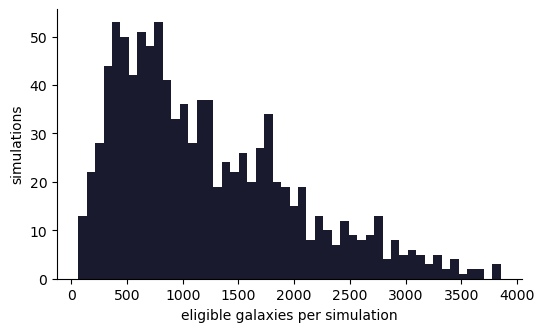

In [3]:
counts_gal = survey_eligible_galaxy_counts(groups_path=GROUPS_PATH)

print(counts_gal["n_eligible"].describe())

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.hist(counts_gal["n_eligible"], bins=50, color="#1a1a2e")
ax.set_xlabel("eligible galaxies per simulation")
ax.set_ylabel("simulations")
ax.spines[["top", "right"]].set_visible(False)

for pct in (1, 5, 10, 25):
    print(f"{pct:>2}th percentile: {np.percentile(counts_gal['n_eligible'], pct):.0f}")


In [4]:
# Drop ~5% of simulations; override by hand after looking at the histogram above.
N_TARGET_GAL = int(np.percentile(counts_gal["n_eligible"], 5))

n_dropped = int((counts_gal["n_eligible"] < N_TARGET_GAL).sum())
print(f"N_TARGET_GAL = {N_TARGET_GAL}")
print(f"would drop {n_dropped} / {len(counts_gal)} simulations")
print(f"mean galaxy separation ~ {config.BOXSIZE / N_TARGET_GAL ** (1/3):.2f} Mpc/h")


N_TARGET_GAL = 262
would drop 50 / 1000 simulations
mean galaxy separation ~ 3.91 Mpc/h


## 3. Generate the fixed-N galaxy run

Set `GENERATE = False` on re-runs once the `.npz` exists.


In [5]:
GENERATE = True

galaxy_path = f"{OUTPUT_DIR}/galaxy_knn_snap{config.SNAP}_M{config.GALAXY_MASS_CUT:.0e}_n{N_TARGET_GAL}.npz"

if GENERATE:
    result_gal = run_galaxy_suite(
        n_target=N_TARGET_GAL, groups_path=GROUPS_PATH, output_dir=OUTPUT_DIR,
    )
else:
    data = np.load(galaxy_path, allow_pickle=True)
    result_gal = {k: data[k] for k in ("sim_ids", "summaries", "nbh", "rgrid", "kvals")}

gal_sim_ids = result_gal["sim_ids"]
gal_summaries = result_gal["summaries"]
gal_nbh = result_gal["nbh"]
gal_rgrid = result_gal["rgrid"]
gal_kvals = result_gal["kvals"]
gal_n_k, gal_n_r = infer_layout(gal_kvals, gal_rgrid)

assert np.all(gal_nbh == N_TARGET_GAL), "galaxy run is not fixed-N -- wrong file?"
print(f"{len(gal_sim_ids)} simulations retained at N={N_TARGET_GAL}, summary shape {gal_summaries.shape}")


Found 1000 group catalogs


  4%|▍         | 42/1000 [00:30<08:41,  1.84it/s] 


FAILED: ../../../Data/Sims/IllustrisTNG/L25n256/LH/LH_15/groups_050.hdf5
  ValueError: Some input data are greater than the size of the periodic box.

  4%|▍         | 43/1000 [00:31<08:16,  1.93it/s]

 17%|█▋        | 168/1000 [01:44<04:04,  3.41it/s]


FAILED: ../../../Data/Sims/IllustrisTNG/L25n256/LH/LH_263/groups_050.hdf5
  ValueError: Negative input data are outside of the periodic box.


100%|██████████| 1000/1000 [10:13<00:00,  1.63it/s]



Saved: ../outputs/galaxy_knn_snap50_M1e+08_n262.npz
Successful runs = 948 / 1000
Summary shape   = (948, 150)
N_GAL: mean 262.0, min 262, max 262
948 simulations retained at N=262, summary shape (948, 150)


## 4. Retention bias, sensitivity

Same fixed-N reasoning as notebook 02: `nbh` is constant by construction,
so no abundance removal is needed, just mean-centring (cosmetic -- the
quartile-diff statistic is invariant to a constant per-bin offset). What
does need checking is which simulations the galaxy cut dropped, since
that's a different eligibility criterion (stellar mass, not luminosity)
than AGN's and could drop a different, differently-biased subset.


In [6]:
theta_all = load_params(PARAMS_FILE)
theta_gal = align_to_params(gal_sim_ids, theta_all)
gal_residuals = gal_summaries - gal_summaries.mean(axis=0)

all_ids = theta_all.index.to_numpy()
retention_diag_gal = diagnose_retention_bias(gal_sim_ids, all_ids, theta_all, params=config.ALL_PARAMS)
display(retention_diag_gal)

for p in config.ALL_PARAMS:
    full = theta_all[p]
    kept = theta_gal[p]
    print(f"{p:>8}: full [{full.min():.3f}, {full.max():.3f}]  "
          f"retained [{kept.min():.3f}, {kept.max():.3f}]")


,parameter,spearman_rho,spearman_p,ks_stat,ks_p,bias_flag
0,Omega_m,0.329908,8.099649e-27,0.038992,0.434910,True
1,sigma_8,0.192203,8.920707e-10,0.022418,0.960894,True
2,A_SN1,-0.225670,5.171163e-13,0.025291,0.903545,True
3,A_AGN1,0.082754,8.841387e-03,0.011793,1.000000,False
4,A_SN2,0.023169,4.642559e-01,0.005646,1.000000,False
5,A_AGN2,-0.037398,2.373742e-01,0.006274,1.000000,False


 Omega_m: full [0.100, 0.500]  retained [0.101, 0.500]
 sigma_8: full [0.600, 1.000]  retained [0.601, 1.000]
   A_SN1: full [0.250, 3.994]  retained [0.250, 3.983]
  A_AGN1: full [0.250, 3.994]  retained [0.250, 3.994]
   A_SN2: full [0.500, 1.999]  retained [0.500, 1.999]
  A_AGN2: full [0.500, 1.999]  retained [0.500, 1.999]


In [7]:
table_gal = sensitivity_table(
    gal_residuals, theta_gal,
    n_k=gal_n_k, rgrid=gal_rgrid, kvals=gal_kvals,
    params=config.ALL_PARAMS,
    n_boot=2000, n_null=2000,
)
summary_gal = summary_dataframe(table_gal)
summary_gal.sort_values("R_obs", ascending=False)


,parameter,R_obs,ci_lo,ci_hi,null_floor,p_value,q_value,significant
0,Omega_m,0.023443,0.020466,0.025957,0.003311,0.0000,0.0000,True
1,sigma_8,0.004884,0.001907,0.008074,0.003122,0.0005,0.0015,True
4,A_SN2,0.003454,0.001274,0.006869,0.003101,0.0315,0.0630,False
2,A_SN1,0.002120,0.000591,0.005294,0.003100,0.1960,0.2940,False
3,A_AGN1,0.001248,0.000568,0.004639,0.003302,0.4955,0.5946,False
5,A_AGN2,0.000510,0.000533,0.003646,0.003162,0.9115,0.9115,False


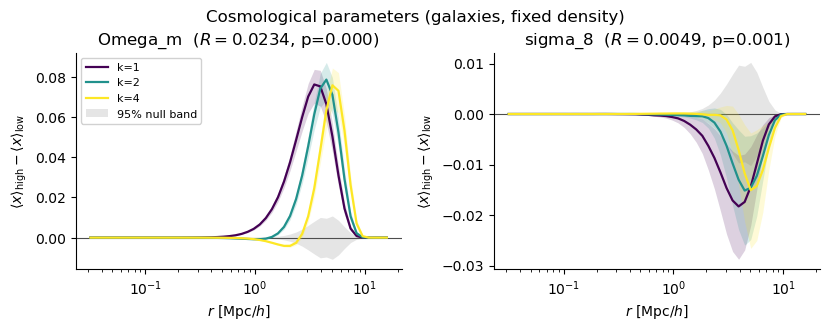

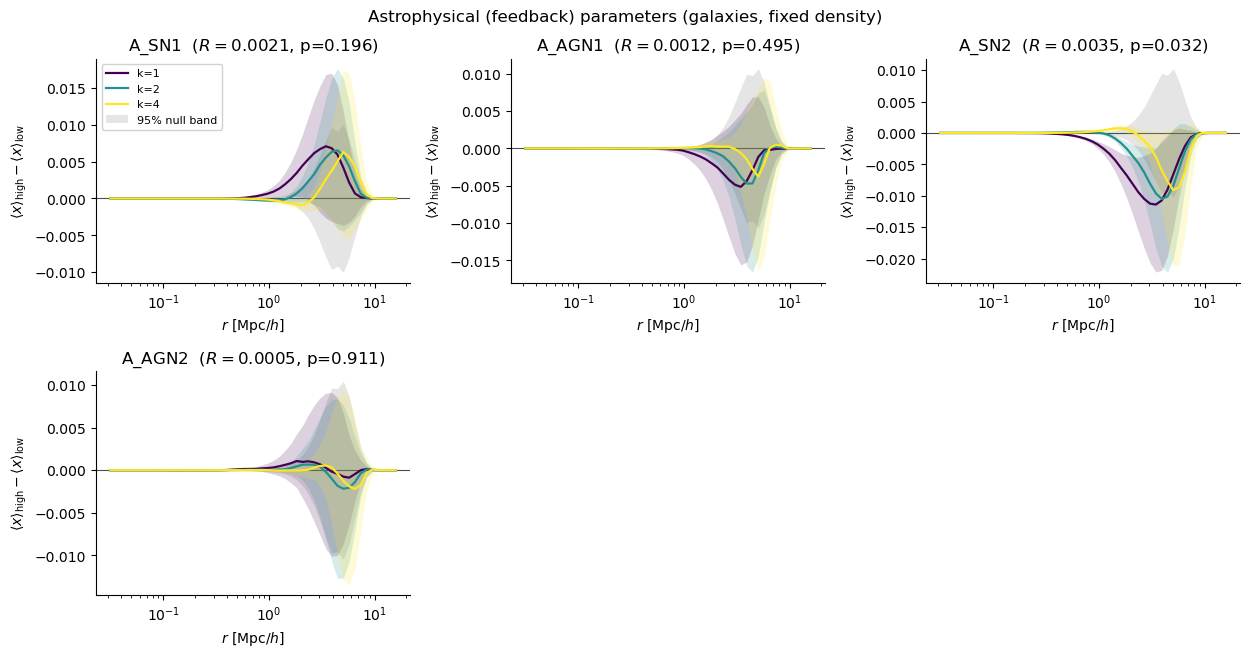

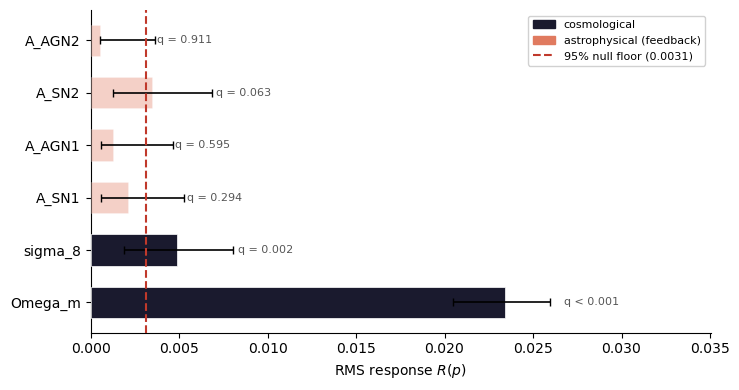

In [8]:
fig, axes = plot_scale_grid(table_gal, params=config.COSMO_PARAMS)
fig.suptitle("Cosmological parameters (galaxies, fixed density)", y=1.02)

fig, axes = plot_scale_grid(table_gal, params=config.ASTRO_PARAMS)
fig.suptitle("Astrophysical (feedback) parameters (galaxies, fixed density)", y=1.02)

fig, ax = plot_sensitivity_bar(summary_gal, config.COSMO_PARAMS, config.ASTRO_PARAMS)


## 5. Side-by-side comparison with AGN

Recomputes the AGN sensitivity table from its saved summaries (notebook
02's `.npz`) so both tables use identical bootstrap/null settings and are
read directly off the same LH suite.


In [9]:
agn_candidates = sorted(glob.glob(f"{OUTPUT_DIR}/agn_knn_snap{config.SNAP}_M{config.MASS_CUT:.0e}_n*.npz"))
assert agn_candidates, f"No AGN fixed-N run found in {OUTPUT_DIR} -- run notebook 02 first."
agn_data = np.load(agn_candidates[-1], allow_pickle=True)
print("Using AGN run:", agn_candidates[-1])

agn_sim_ids = agn_data["sim_ids"]
agn_theta = align_to_params(agn_sim_ids, theta_all)
agn_residuals = agn_data["summaries"] - agn_data["summaries"].mean(axis=0)
agn_n_k, agn_n_r = infer_layout(agn_data["kvals"], agn_data["rgrid"])

table_agn = sensitivity_table(
    agn_residuals, agn_theta,
    n_k=agn_n_k, rgrid=agn_data["rgrid"], kvals=agn_data["kvals"],
    params=config.ALL_PARAMS, n_boot=2000, n_null=2000,
)
summary_agn = summary_dataframe(table_agn)

comparison = (
    summary_agn.set_index("parameter")[["R_obs", "q_value", "significant"]].add_suffix("_agn")
    .join(summary_gal.set_index("parameter")[["R_obs", "q_value", "significant"]].add_suffix("_galaxy"))
)
comparison


Using AGN run: ../outputs/agn_knn_snap50_M1e+06_n286.npz


,R_obs_agn,q_value_agn,significant_agn,R_obs_galaxy,q_value_galaxy,significant_galaxy
parameter,,,,,,
Omega_m,0.020685,0.00000,True,0.023443,0.0000,True
sigma_8,0.001879,0.61650,False,0.004884,0.0015,True
A_SN1,0.000970,0.84675,False,0.002120,0.2940,False
A_AGN1,0.000470,0.91050,False,0.001248,0.5946,False
A_SN2,0.001216,0.84675,False,0.003454,0.0630,False
A_AGN2,0.000464,0.91050,False,0.000510,0.9115,False


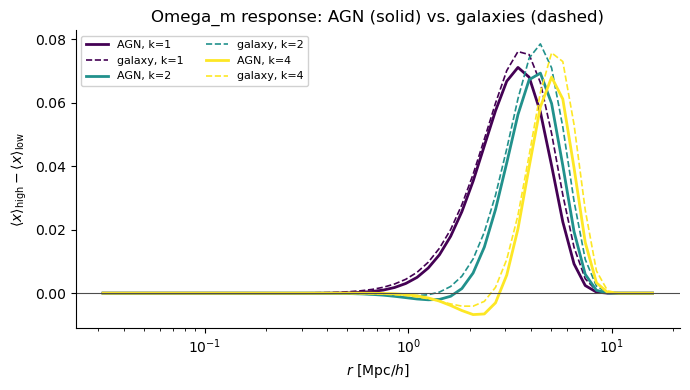

In [10]:
fig, ax = plt.subplots(figsize=(7, 4))

cmap = plt.get_cmap("viridis")
for ki in range(agn_n_k):
    colour = cmap(ki / max(agn_n_k - 1, 1))
    ax.plot(agn_data["rgrid"], table_agn["Omega_m"]["obs"][ki], color=colour, lw=2,
            label=f"AGN, k={agn_data['kvals'][ki]}")
    ax.plot(gal_rgrid, table_gal["Omega_m"]["obs"][ki], color=colour, lw=1.2, ls="--",
            label=f"galaxy, k={gal_kvals[ki]}")

ax.axhline(0, color="0.3", lw=0.8)
ax.set_xscale("log")
ax.set_xlabel(r"$r\ [\mathrm{Mpc}/h]$")
ax.set_ylabel(r"$\langle x\rangle_{\rm high} - \langle x\rangle_{\rm low}$")
ax.set_title("Omega_m response: AGN (solid) vs. galaxies (dashed)")
ax.legend(fontsize=8, framealpha=0.9, ncol=2)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()


## 6. Do the two tracers fluctuate together? (the direct complementarity check)

Section 5 compares *parameter responses* -- but two tracers could show
the same parameters as significant while still carrying different
information about any single simulation's particular realization of
structure. The direct check: for simulations common to both fixed-N runs
(the two selections can drop different simulations), correlate the two
tracers' per-bin residuals across the suite.

A value near +-1 at some (k, r) means galaxy and AGN clustering
fluctuations track each other there -- largely redundant. A value near 0
means they're independent at that scale -- complementary, and a joint
analysis using both would carry more information than either alone.

A bin can come out `NaN` (a gap in the plot) if either tracer's residual has essentially zero variance there across the suite -- the same pinned-CDF-at-small/large-r effect notebook 02 (section 6) describes: every simulation's CDF is 0 below its smallest tracer separation and 1 above its largest, so there's no fluctuation for a bin there to correlate.


927 simulations common to both fixed-N runs (950 AGN, 948 galaxy)
median |correlation| = 0.691
max |correlation|    = 0.921


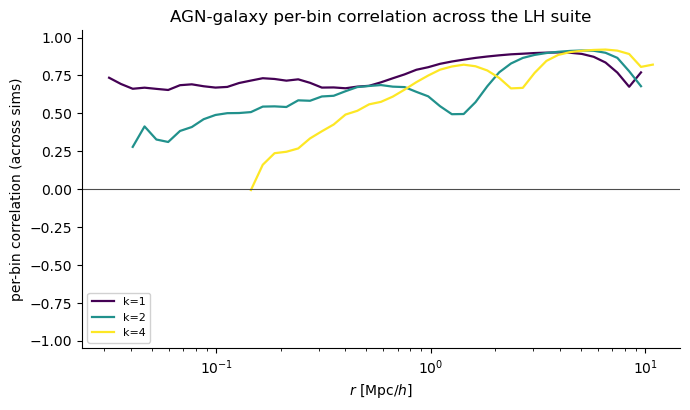

In [11]:
common_ids, agn_common, gal_common = align_common_sims(
    agn_sim_ids, agn_residuals, gal_sim_ids, gal_residuals,
)
print(f"{len(common_ids)} simulations common to both fixed-N runs "
      f"({len(agn_sim_ids)} AGN, {len(gal_sim_ids)} galaxy)")

assert agn_n_k == gal_n_k and len(agn_data["rgrid"]) == len(gal_rgrid), (
    "AGN and galaxy runs used different kvals/rgrid -- not directly comparable."
)

corr = bin_correlation(agn_common, gal_common).reshape(agn_n_k, agn_n_r)

fig, ax = plot_bin_correlation(gal_rgrid, gal_kvals, corr)
ax.set_title("AGN-galaxy per-bin correlation across the LH suite")

print(f"median |correlation| = {np.nanmedian(np.abs(corr)):.3f}")
print(f"max |correlation|    = {np.nanmax(np.abs(corr)):.3f}")


## Reading this

Three independent angles on "complementary vs. redundant", read together:

- **Section 5's table**: if AGN and galaxies are significant for the same
  parameters (almost certainly just `Omega_m`, per every earlier
  notebook) and null for the same ones, that alone doesn't distinguish
  redundant from complementary -- both could be significant for `Omega_m`
  while still fluctuating independently simulation-to-simulation, or
  moving in lockstep.
- **Section 5's `Omega_m` overlay**: if the galaxy and AGN curves have a
  similar shape and comparable amplitude, both tracers are picking up the
  same *kind* of clustering response to `Omega_m`, for whatever that's
  worth for a joint analysis' error budget.
- **Section 6's correlation** is the direct test: high |correlation|
  across most (k, r) means the two tracers are substantially redundant --
  a joint kNN-CDF analysis wouldn't add much over either tracer alone,
  because both are largely reading off the same realization of large-scale
  structure. Low correlation means the opposite: each tracer has its own,
  largely independent view of the same box, and combining them (e.g. a
  joint likelihood, or a cross-tracer kNN statistic) is a real avenue for
  tightening a future degeneracy-breaking analysis, not just a
  cross-check.

Unlike every other significance claim in this project, section 6's
correlation has no permutation null attached to it -- it's a descriptive
statistic across `len(common_ids)` simulations, not a hypothesis test.
Read a value as "how strongly", not "significantly vs. chance".
